In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import numpy as np
from scipy import stats
import os, json


def draw_ratio_vs_enrtopy(file_path, model_name):
    
    image_entropy_list = []
    image_ratio_list = []
    relevant_ratio_list = []
    efr_list = []

    # file_path = os.path.join(root, file_name)
    with open(file_path, "r") as f:
        bbox_data = json.load(f)

    ori_q_att_info = bbox_data["ori_q_att_info"]

    for layer, heads in ori_q_att_info.items():
        for head, e1 in heads.items():
            image_entropy = e1["image_entropy"]
            image_ratio = e1["image_ratio"]
            relevant_ratio = e1["relevant_ratio"]

            
        # relevant_ratio_list.append(relevant_ratio)

            # 避免除零
            # 统一检查：两个值都必须合法
            if image_ratio > 1e-12 and np.isfinite(image_entropy):
                image_entropy_list.append(image_entropy)
                image_ratio_list.append(image_ratio)
                relevant_ratio_list.append(relevant_ratio)




    # ------------------- 全局字体和风格 -------------------
    f_size = 25
    plt.rcParams.update({
        'font.size': f_size,
        'font.weight': 'normal',
        'axes.labelsize': 'x-large',
        'font.sans-serif':'DejaVu Sans',
        'font.family': ['DejaVu Sans'],
        'axes.facecolor':'snow',
    })
    plt.rcParams['pdf.fonttype'] = 42
    plt.rcParams['ps.fonttype'] = 42

    # ------------------- 数据准备 -------------------
    image_entropy = np.array(image_entropy_list)
    image_ratio = np.array(image_ratio_list)
    relevant_ratio = np.array(relevant_ratio_list)

    # 线性拟合 y = k*x + b
    X = image_entropy.reshape(-1, 1)
    y = image_ratio
    reg = LinearRegression().fit(X, y)
    y_pred = reg.predict(X)
    k = reg.coef_[0]
    b = reg.intercept_

    # Pearson R
    R, _ = pearsonr(image_entropy, image_ratio)
    formula = f"$R_{{img}} = {k:.3f} H_{{img}} + {b:.3f}, R={R:.3f}$"

    # ------------------- 绘图 -------------------
    plt.figure(figsize=(12, 12))
    sc = plt.scatter(image_entropy, image_ratio, c=relevant_ratio, cmap="viridis",
                    alpha=0.7, edgecolor='k', linewidth=0.3, s=50)

    plt.plot(image_entropy, y_pred, color='red', linewidth=2, label=formula)

    # 优化标签
    plt.colorbar(sc, label="Relevant Region Attention Ratio")
    plt.xlabel(f"Image Attention Entropy($R_{{img}}$)")
    plt.ylabel(f"Image Attention Ratio($H_{{img}}$)")
    plt.title(model_name)
    plt.legend(loc="upper left", bbox_to_anchor=(-0.05, -0.15))  # 图外左下角
    plt.tight_layout()
    plt.savefig(f"/linear_Attention_Entropy_{model_name}.jpg",  dpi=1000)
    plt.show()

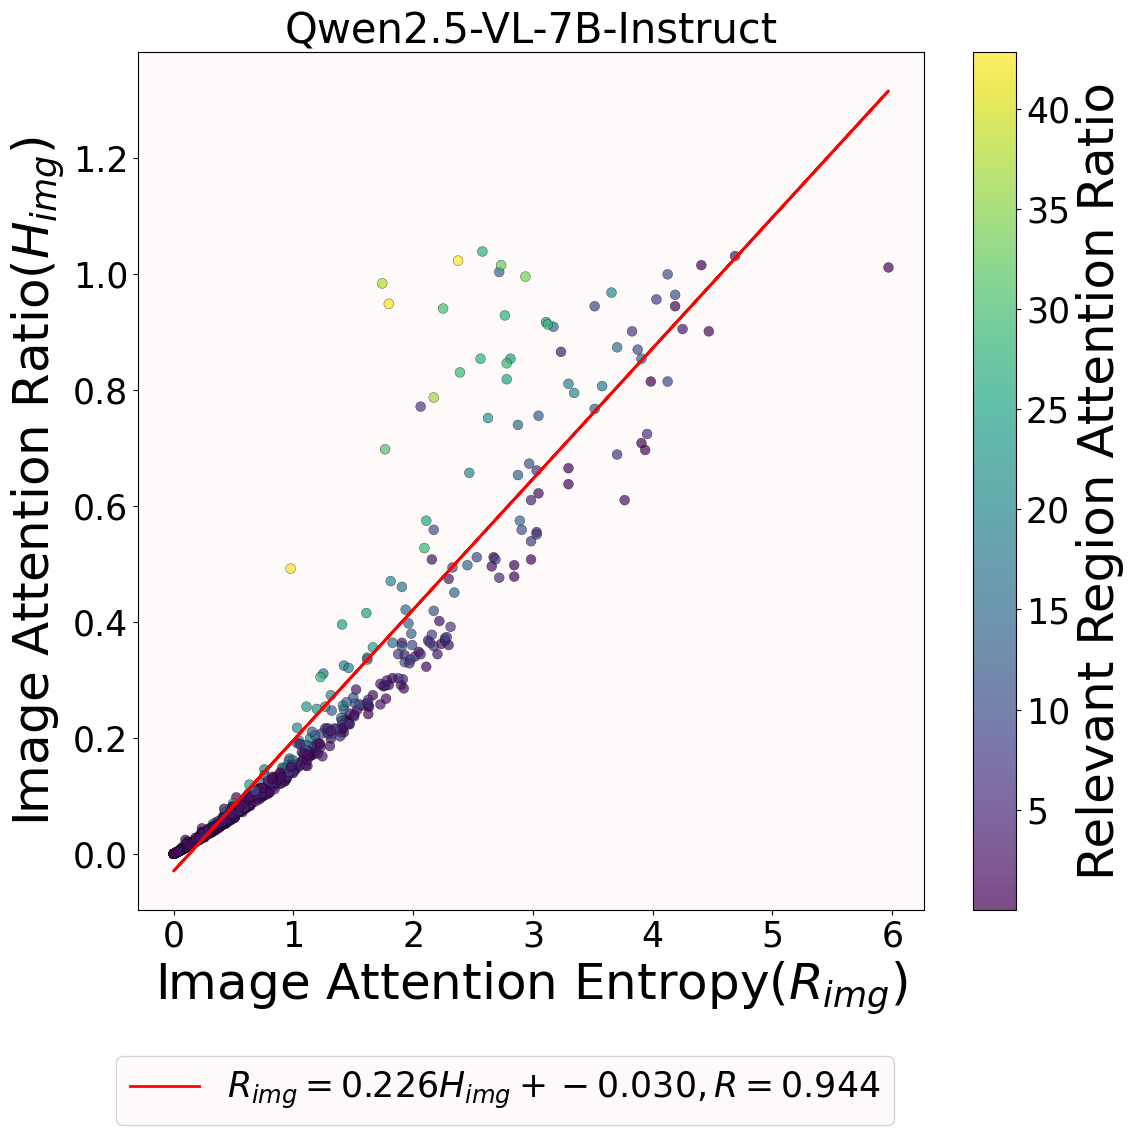

In [3]:
file_path = "./outputs/example/bbox_ratio/34607_1447.json"
model_name = "Qwen2.5-VL-7B-Instruct"
draw_ratio_vs_enrtopy(file_path, model_name)